In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

from skimage.filters import threshold_otsu
from skimage.measure import label, regionprops
from skimage.morphology import skeletonize, remove_small_objects

from sklearn.ensemble import RandomForestClassifier


data_dir = Path("../data/cropped")

output_dir = Path("../outputs/rgc_image_analysis")
fig_dir = output_dir / "figures"

output_dir.mkdir(
    parents=True,
    exist_ok=True
)

fig_dir.mkdir(
    parents=True,
    exist_ok=True
)


assignments = pd.read_csv(
    output_dir / "rgc_cluster_assignments.csv"
)

display(assignments.head())

,image_index,filename,kmeans_cluster,hierarchical_cluster
0,0,cropped0.tif,2,1
1,1,cropped1.tif,1,3
2,2,cropped10.tif,1,3
3,3,cropped11.tif,2,1
4,4,cropped12.tif,2,1


In [2]:
def extract_morph_features(image_path):

    img = Image.open(
        image_path
    ).convert("L")

    arr = np.array(
        img
    ).astype(float)

    arr_norm = (
        arr - arr.min()
    ) / (
        arr.max() - arr.min() + 1e-8
    )

    threshold = threshold_otsu(
        arr_norm
    )

    mask = arr_norm > threshold

    mask = remove_small_objects(
        mask,
        max_size=19
    )

    labeled = label(
        mask
    )

    props = regionprops(
        labeled
    )

    features = {
        "mean_intensity": arr_norm.mean(),
        "std_intensity": arr_norm.std(),
        "foreground_fraction": mask.mean(),
        "foreground_area_pixels": mask.sum(),
        "skeleton_length": skeletonize(mask).sum()
    }

    if len(props) > 0:

        largest = max(
            props,
            key=lambda p: p.area
        )

        minr, minc, maxr, maxc = largest.bbox

        bbox_height = maxr - minr
        bbox_width = maxc - minc

        features.update({
            "largest_object_area": largest.area,
            "bbox_area": bbox_height * bbox_width,
            "bbox_aspect_ratio": bbox_width / (bbox_height + 1e-8),
            "eccentricity": largest.eccentricity,
            "solidity": largest.solidity,
            "perimeter": largest.perimeter
        })

    else:

        features.update({
            "largest_object_area": 0,
            "bbox_area": 0,
            "bbox_aspect_ratio": np.nan,
            "eccentricity": np.nan,
            "solidity": np.nan,
            "perimeter": 0
        })

    return features


rows = []

for _, row in assignments.iterrows():

    image_path = data_dir / row["filename"]

    features = extract_morph_features(
        image_path
    )

    features["image_index"] = row["image_index"]
    features["filename"] = row["filename"]
    features["kmeans_cluster"] = row["kmeans_cluster"]
    features["hierarchical_cluster"] = row["hierarchical_cluster"]

    rows.append(
        features
    )


morph_features = pd.DataFrame(
    rows
)

morph_features_path = output_dir / "rgc_morph_features_simple.csv"

morph_features.to_csv(
    morph_features_path,
    index=False
)

display(
    morph_features.head()
)

print(
    "Saved:",
    morph_features_path
)

,mean_intensity,std_intensity,foreground_fraction,foreground_area_pixels,skeleton_length,largest_object_area,bbox_area,bbox_aspect_ratio,eccentricity,solidity,perimeter,image_index,filename,kmeans_cluster,hierarchical_cluster
0,0.994282,0.052436,0.989399,259365,1512,259171.0,262144,1.0,0.234487,0.994780,2376.995995,0,cropped0.tif,2,1
1,0.923190,0.249474,0.915245,239926,452,239926.0,262144,1.0,0.530769,0.994982,1956.516811,1,cropped1.tif,1,3
2,0.928054,0.235099,0.921787,241641,3077,241617.0,262144,1.0,0.523452,0.989609,2133.263023,2,cropped10.tif,1,3
3,0.998677,0.020653,0.996792,261303,6795,261303.0,262144,1.0,0.078581,0.996792,3483.014465,3,cropped11.tif,2,1
4,0.956082,0.106097,0.877590,230055,21569,229217.0,262144,1.0,0.352179,0.874544,15566.662833,4,cropped12.tif,2,1


Saved: ../outputs/rgc_image_analysis/rgc_morph_features_simple.csv


In [3]:
feature_cols = [
    "mean_intensity",
    "std_intensity",
    "foreground_fraction",
    "foreground_area_pixels",
    "skeleton_length",
    "largest_object_area",
    "bbox_area",
    "bbox_aspect_ratio",
    "eccentricity",
    "solidity",
    "perimeter"
]


importance_rows = []


for cluster_col in [
    "kmeans_cluster",
    "hierarchical_cluster"
]:

    rf_df = morph_features.dropna(
        subset=feature_cols + [cluster_col]
    )

    X = rf_df[
        feature_cols
    ]

    y = rf_df[
        cluster_col
    ]

    model = RandomForestClassifier(
        n_estimators=500,
        random_state=42,
        class_weight="balanced"
    )

    model.fit(
        X,
        y
    )

    importances = pd.DataFrame({
        "cluster_method": cluster_col,
        "feature": feature_cols,
        "importance": model.feature_importances_
    })

    importance_rows.append(
        importances
    )


importance_df = pd.concat(
    importance_rows,
    ignore_index=True
)

importance_path = output_dir / "rgc_random_forest_feature_importance.csv"

importance_df.to_csv(
    importance_path,
    index=False
)

display(
    importance_df.sort_values(
        ["cluster_method", "importance"],
        ascending=[True, False]
    )
)

print(
    "Saved:",
    importance_path
)

,cluster_method,feature,importance
21,hierarchical_cluster,perimeter,0.188846
15,hierarchical_cluster,skeleton_length,0.153191
20,hierarchical_cluster,solidity,0.149047
12,hierarchical_cluster,std_intensity,0.102227
11,hierarchical_cluster,mean_intensity,0.079205
13,hierarchical_cluster,foreground_fraction,0.077999
14,hierarchical_cluster,foreground_area_pixels,0.073613
16,hierarchical_cluster,largest_object_area,0.071351
19,hierarchical_cluster,eccentricity,0.057598
17,hierarchical_cluster,bbox_area,0.025169


Saved: ../outputs/rgc_image_analysis/rgc_random_forest_feature_importance.csv


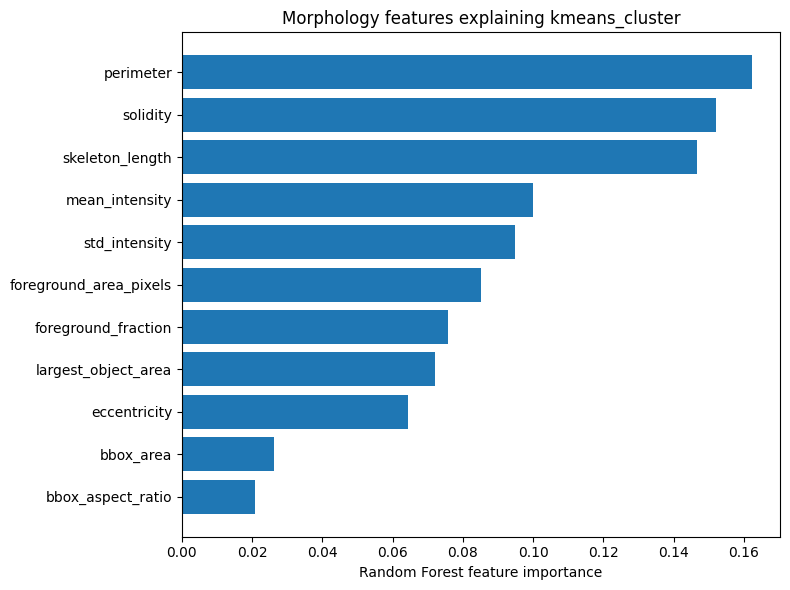

Saved: ../outputs/rgc_image_analysis/figures/kmeans_cluster_random_forest_feature_importance.tiff


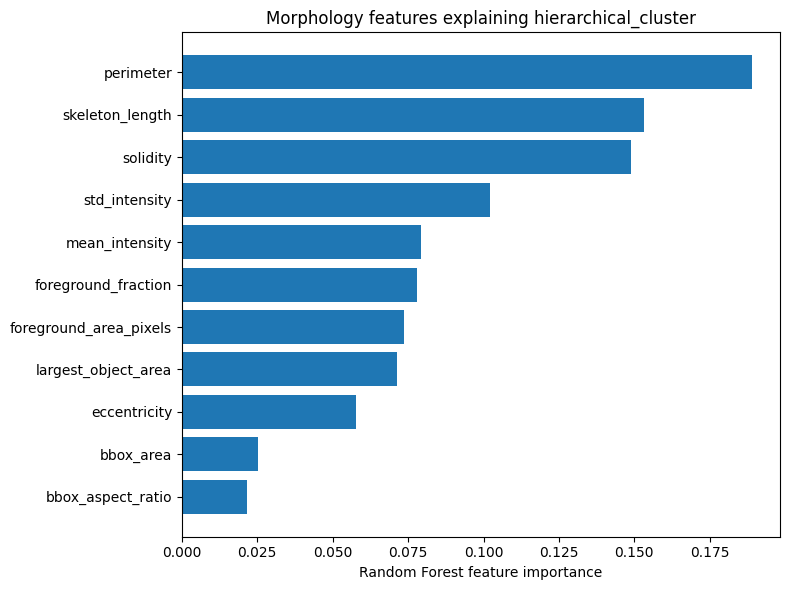

Saved: ../outputs/rgc_image_analysis/figures/hierarchical_cluster_random_forest_feature_importance.tiff


In [4]:
for cluster_method in importance_df["cluster_method"].unique():

    plot_df = importance_df[
        importance_df["cluster_method"] == cluster_method
    ].sort_values(
        "importance"
    )

    plt.figure(
        figsize=(8, 6)
    )

    plt.barh(
        plot_df["feature"],
        plot_df["importance"]
    )

    plt.xlabel(
        "Random Forest feature importance"
    )

    plt.title(
        f"Morphology features explaining {cluster_method}"
    )

    plt.tight_layout()

    out_path = fig_dir / f"{cluster_method}_random_forest_feature_importance.tiff"

    plt.savefig(
        out_path,
        dpi=300,
        format="tiff",
        bbox_inches="tight"
    )

    plt.show()

    print(
        "Saved:",
        out_path
    )